# Import Libraries and create a pipeline

In [70]:
import spacy

In [71]:
nlp = spacy.load('en_core_web_sm') # 'en_core_web_sm' is a pretrained language model in spacy

# Create a doc object with nlp() function

In [72]:
mystring = "Apple is looking at buying U.K. startup for $1 billion."

In [73]:
doc = nlp(mystring)

# Tokenize mystring and print the tokens

In [74]:
for token in doc:
    print(token.text)

Apple
is
looking
at
buying
U.K.
startup
for
$
1
billion
.


In [75]:
for token in doc:
    print(token.text, end=' | ') # using the pipe operator to separate the tokens.

Apple | is | looking | at | buying | U.K. | startup | for | $ | 1 | billion | . | 

In [76]:
for token in doc:
    print(token.text,token.pos_)

Apple PROPN
is AUX
looking VERB
at ADP
buying VERB
U.K. PROPN
startup NOUN
for ADP
$ SYM
1 NUM
billion NUM
. PUNCT


# Import beautifultable for proper display of tokens and POS

In [77]:
!pip install beautifultable

In [78]:
from beautifultable import BeautifulTable

In [79]:
table = BeautifulTable()
table.columns.header = ["text token", "POS"]
for token in doc:
  table.rows.append([token.text, token.pos_])

print(table)

+------------+-------+
| text token |  POS  |
+------------+-------+
|   Apple    | PROPN |
+------------+-------+
|     is     |  AUX  |
+------------+-------+
|  looking   | VERB  |
+------------+-------+
|     at     |  ADP  |
+------------+-------+
|   buying   | VERB  |
+------------+-------+
|    U.K.    | PROPN |
+------------+-------+
|  startup   | NOUN  |
+------------+-------+
|    for     |  ADP  |
+------------+-------+
|     $      |  SYM  |
+------------+-------+
|     1      |  NUM  |
+------------+-------+
|  billion   |  NUM  |
+------------+-------+
|     .      | PUNCT |
+------------+-------+


## spacy.explain() to see the full name

In [80]:
spacy.explain('PROPN')

'proper noun'

In [81]:
spacy.explain('ADP')

'adposition'

In [82]:
spacy.explain('AUX')

'auxiliary'

In [83]:
spacy.explain('SYM')

'symbol'

In [84]:
# For definition of each POS Tag visit  https://universaldependencies.org/u/pos/

#  Steps of Tokenization

In [85]:
# Reference : https://ashutoshtripathi.com/2020/04/06/guide-to-tokenization-lemmatization-stop-words-and-phrase-matching-using-spacy/

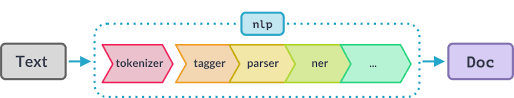

In [86]:
doc2 = nlp( '"Next Week, We’re coming from U.S.!\"')
for token in doc2:
     print(token.text, end=' | ')

" | Next | Week | , | We | ’re | coming | from | U.S. | ! | " | 

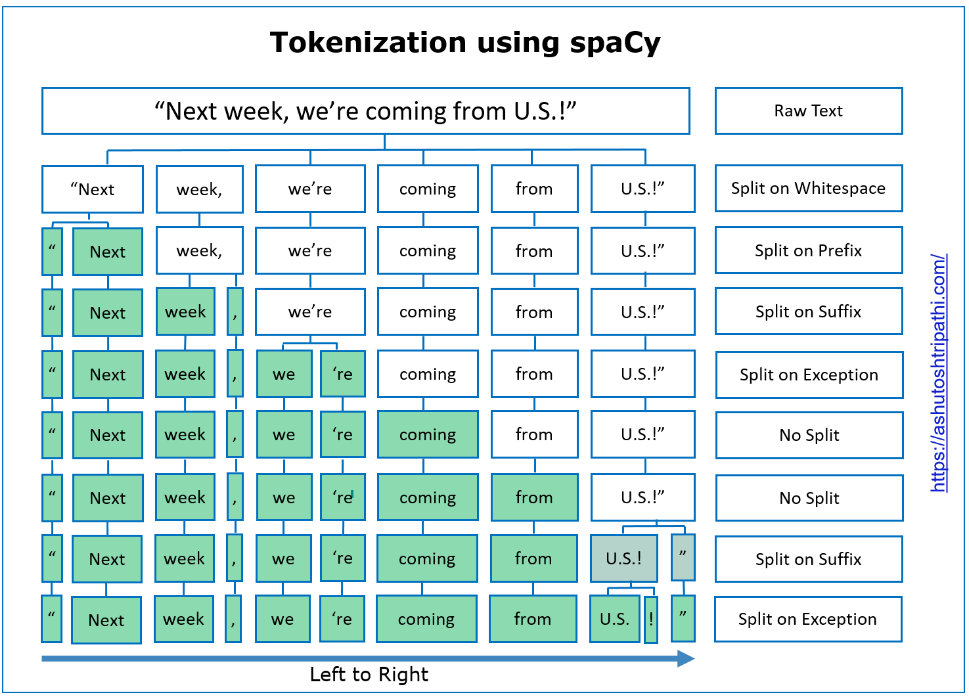

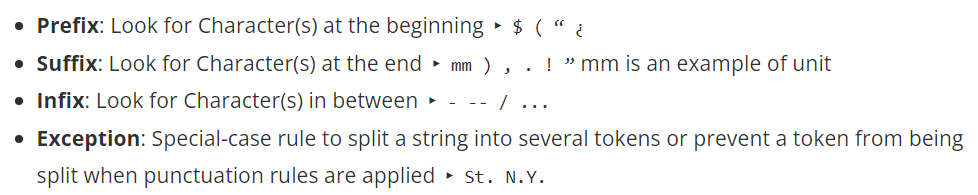

## Examples

In [87]:
doc3 = nlp("We're here to help you! ask the question, email support@abcnet.ax or visit us at http://www.abcnet.ax!")

In [88]:
for token in doc3:
     print(token.text)

We
're
here
to
help
you
!
ask
the
question
,
email
support@abcnet.ax
or
visit
us
at
http://www.abcnet.ax
!


In [89]:
# Note that the exclamation mark and comma are assigned separate tokens.
# However spacy is smart enough to preserve point, colon in email address and URL.

In [90]:
doc4 = nlp('A 40km U.S. cab ride costs $100.60.')
for token in doc4:
    print(token.text)

A
40
km
U.S.
cab
ride
costs
$
100.60
.


In [91]:
# Note that in amount the point is preserved.

In [92]:
doc5 = nlp("Let's visit the St. Louis in the U.S. next year.")
for token in doc5:
    print(token.text)

Let
's
visit
the
St.
Louis
in
the
U.S.
next
year
.


In [93]:
# Note that the abbreviations for “Saint” and “United States” are both preserved.

# Number of Tokens

In [94]:
len(doc5)

12

# Vocab Entries

In [95]:
len(doc5.vocab)

802

# Syntactic Dependencies

### A syntactic dependency is a relation between two words in a sentence with one word being the Independent and the other being the dependent of the relation

In [96]:
my_string = "Google is looking at buying U.K startup for $5 billion."

In [97]:
doc = nlp(my_string)

In [98]:
table = BeautifulTable()

In [99]:
table.columns.header = ['Tokens', 'POS', 'TAG', 'Explain Tag', 'Dep', 'is_alpha', 'is_stop']
for token in doc:
  table.rows.append([token.text, token.pos_, token.tag_, spacy.explain(token.tag_),token.dep_, token.is_alpha, token.is_stop])

In [100]:
print(table)

+---------+-------+-----+----------------------+----------+----------+---------+
| Tokens  |  POS  | TAG |     Explain Tag      |   Dep    | is_alpha | is_stop |
+---------+-------+-----+----------------------+----------+----------+---------+
| Google  | PROPN | NNP | noun, proper singula |  nsubj   |    1     |    0    |
|         |       |     |          r           |          |          |         |
+---------+-------+-----+----------------------+----------+----------+---------+
|   is    |  AUX  | VBZ | verb, 3rd person sin |   aux    |    1     |    1    |
|         |       |     |    gular present     |          |          |         |
+---------+-------+-----+----------------------+----------+----------+---------+
| looking | VERB  | VBG | verb, gerund or pres |   ROOT   |    1     |    0    |
|         |       |     |    ent participle    |          |          |         |
+---------+-------+-----+----------------------+----------+----------+---------+
|   at    |  ADP  | IN  | co

In [101]:
# is_alpha means "Is token an alphabetic character"

In [102]:
# For List of attributes https://spacy.io/api/token#attributes

In [103]:
# For complete information of syntactic dependencies visit https://downloads.cs.stanford.edu/nlp/software/dependencies_manual.pdf

In [104]:
spacy.explain('NNP')

'noun, proper singular'

In [105]:
spacy.explain('nsubj')

'nominal subject'

In [106]:
spacy.explain('dep')

'unclassified dependent'

# Visualizing dependencies

In [107]:
from spacy import displacy

In [108]:
options = {"distance":110}
displacy.render(doc, style='dep', jupyter=True, options=options)

# Sentence Boundary Detection

In [110]:
para = "Weather is good. We are learning NLP. This is a good course"

In [111]:
doc = nlp(para)

In [112]:
list(doc) # shows the list of tokens

[Weather, is, good, ., We, are, learning, NLP, ., This, is, a, good, course]

In [113]:
sents = list(doc.sents) # shows the list of sentences

In [114]:
sents

[Weather is good., We are learning NLP., This is a good course]

In [115]:
len(sents)

3

In [116]:
for sent in sents:
  print(sent)

Weather is good.
We are learning NLP.
This is a good course


In [117]:
doc[5]

are

In [118]:
doc[0].is_sent_start

True

In [119]:
doc[4].is_sent_end

False

# Tokenization With NLTK

In [120]:
import nltk
from nltk import word_tokenize

# NLTK Language Model

In [121]:
nltk.download("wordnet") # It helps find conceptual relationship between the words
nltk.download('punkt') # It is pretrained tokenizer for English
nltk.download('averaged_perceptron_tagger') # Pretrained english POS Tagger
nltk.download('omw-1.4') # Open multilingual wordnet. The goal is to make it easy to use wordnets in multiple languages.

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [122]:
doc = '"Next Week, We’re coming from U.S.!\"'

In [123]:
for token in word_tokenize(doc):
  print(token, end=' | ')

`` | Next | Week | , | We | ’ | re | coming | from | U.S. | ! | '' | 

In [124]:
doc1 = "We're here to help you! ask the question, email support@abcnet.ax or visit us at http://www.abcnet.ax!"

In [125]:
for token in word_tokenize(doc1):
  print(token)

We
're
here
to
help
you
!
ask
the
question
,
email
support
@
abcnet.ax
or
visit
us
at
http
:
//www.abcnet.ax
!
